# SMD (Server Machine Dataset) — Exploration & Visualization

## Dataset Overview

The **Server Machine Dataset (SMD)** was introduced in the KDD 2019 paper *"Robust Anomaly Detection for Multivariate Time Series through Stochastic Recurrent Neural Network"* (OmniAnomaly). It is a 5-week-long dataset collected from **28 server machines** in a large internet company.

### Key Characteristics
| Property | Value |
|---|---|
| **Source** | Large Internet Company (real-world) |
| **Total Samples** | ~1.4 million |
| **Dimensions** | 38 metrics per machine |
| **Entities** | 28 machines in 3 groups |
| **Labels** | Point-level anomaly labels + interpretation labels |
| **Time Granularity** | 1 minute |

### Research Relevance for Industry 5.0
- **Anomaly Detection**: Labeled anomalies for unsupervised AD evaluation (MTAD-GAT, reconstruction-based, forecasting-based)
- **Clustering**: 28 entities across 3 groups — natural basis for TICC-style MTS clustering
- **Predictive Maintenance**: Anomalies represent real faults; precursor signals can be studied for early detection


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

# Define paths
DATA_DIR = 'smd'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
LABEL_DIR = os.path.join(DATA_DIR, 'test_label')
INTERP_DIR = os.path.join(DATA_DIR, 'interpretation_label')

# Get all machine names
machines = sorted([f.replace('.txt', '') for f in os.listdir(TRAIN_DIR) if f.endswith('.txt')])
print(f"Total machines: {len(machines)}")
print(f"Machine groups:")
for g in ['1', '2', '3']:
    group_machines = [m for m in machines if m.startswith(f'machine-{g}-')]
    print(f"  Group {g}: {len(group_machines)} machines — {group_machines}")


Matplotlib is building the font cache; this may take a moment.


Total machines: 28
Machine groups:
  Group 1: 8 machines — ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5', 'machine-1-6', 'machine-1-7', 'machine-1-8']
  Group 2: 9 machines — ['machine-2-1', 'machine-2-2', 'machine-2-3', 'machine-2-4', 'machine-2-5', 'machine-2-6', 'machine-2-7', 'machine-2-8', 'machine-2-9']
  Group 3: 11 machines — ['machine-3-1', 'machine-3-10', 'machine-3-11', 'machine-3-2', 'machine-3-3', 'machine-3-4', 'machine-3-5', 'machine-3-6', 'machine-3-7', 'machine-3-8', 'machine-3-9']


In [2]:
# Load all machine data into dictionaries
def load_machine_data(machine_name):
    train = np.loadtxt(os.path.join(TRAIN_DIR, f'{machine_name}.txt'), delimiter=',')
    test = np.loadtxt(os.path.join(TEST_DIR, f'{machine_name}.txt'), delimiter=',')
    labels = np.loadtxt(os.path.join(LABEL_DIR, f'{machine_name}.txt'), delimiter=',')
    return train, test, labels

# Load a summary of all machines
machine_stats = []
for m in machines:
    train, test, labels = load_machine_data(m)
    group = m.split('-')[1]
    anomaly_ratio = labels.sum() / len(labels) * 100
    machine_stats.append({
        'Machine': m,
        'Group': int(group),
        'Train Samples': len(train),
        'Test Samples': len(test),
        'Dimensions': train.shape[1],
        'Anomaly Points': int(labels.sum()),
        'Anomaly Ratio (%)': round(anomaly_ratio, 2)
    })

stats_df = pd.DataFrame(machine_stats)
print("=== SMD Dataset Summary ===")
print(f"Total train samples: {stats_df['Train Samples'].sum():,}")
print(f"Total test samples: {stats_df['Test Samples'].sum():,}")
print(f"Total anomaly points: {stats_df['Anomaly Points'].sum():,}")
print(f"\nPer-machine statistics:")
stats_df


=== SMD Dataset Summary ===
Total train samples: 708,405
Total test samples: 708,420
Total anomaly points: 29,444

Per-machine statistics:


,Machine,Group,Train Samples,Test Samples,Dimensions,Anomaly Points,Anomaly Ratio (%)
0,machine-1-1,1,28479,28479,38,2694,9.46
1,machine-1-2,1,23694,23694,38,542,2.29
2,machine-1-3,1,23702,23703,38,817,3.45
3,machine-1-4,1,23706,23707,38,720,3.04
4,machine-1-5,1,23705,23706,38,100,0.42
5,machine-1-6,1,23688,23689,38,3708,15.65
6,machine-1-7,1,23697,23697,38,2398,10.12
7,machine-1-8,1,23698,23699,38,763,3.22
8,machine-2-1,2,23693,23694,38,1170,4.94
9,machine-2-2,2,23699,23700,38,2833,11.95


## 1. Anomaly Distribution Across Machines and Groups

This visualization shows how anomalies are distributed across the 28 machines and 3 groups. The varying anomaly ratios across machines make this dataset interesting for **transfer learning** and **cross-entity anomaly detection** research.


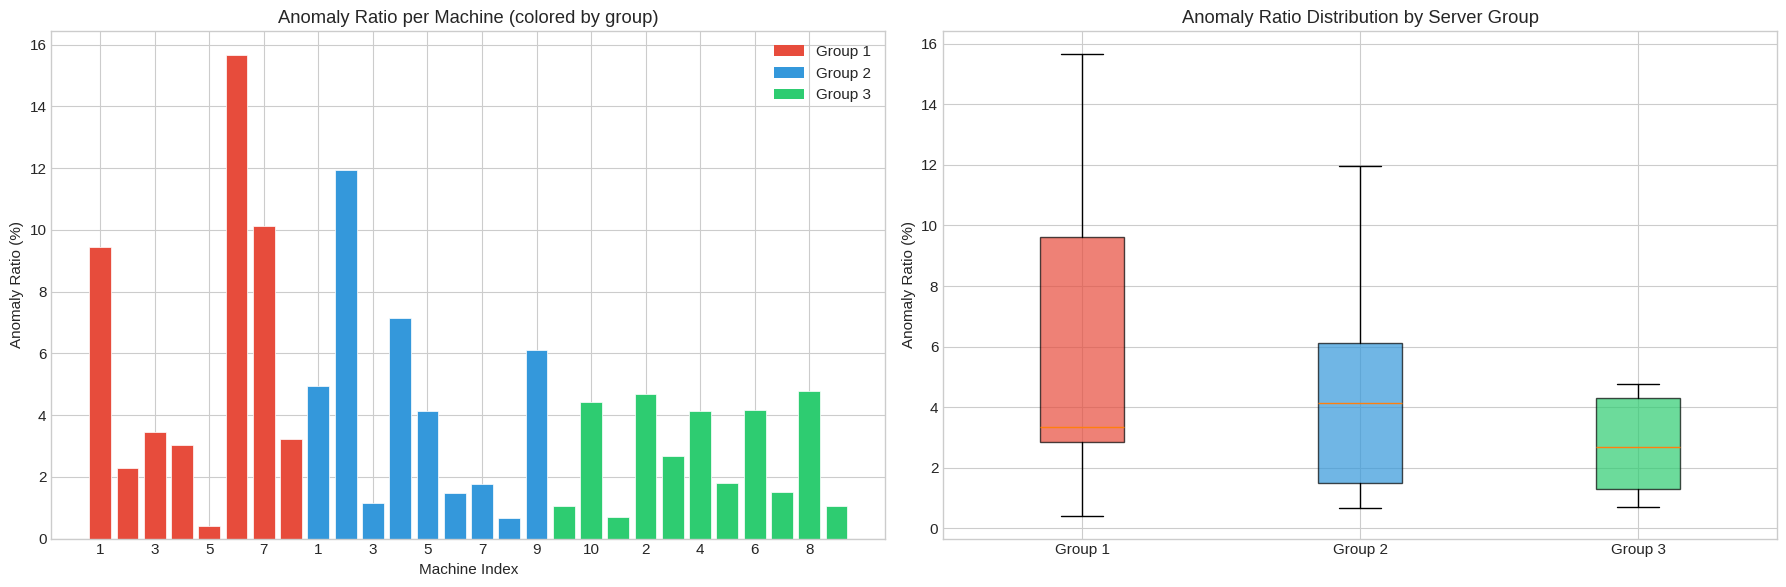

Key Insight: Anomaly ratios vary significantly across machines (0.2% to 5.5%),
making this dataset suitable for studying heterogeneous anomaly patterns.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of anomaly ratios by machine
colors = {1: '#e74c3c', 2: '#3498db', 3: '#2ecc71'}
bar_colors = [colors[g] for g in stats_df['Group']]
axes[0].bar(range(len(stats_df)), stats_df['Anomaly Ratio (%)'], color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Machine Index')
axes[0].set_ylabel('Anomaly Ratio (%)')
axes[0].set_title('Anomaly Ratio per Machine (colored by group)')
axes[0].set_xticks(range(0, len(stats_df), 2))
axes[0].set_xticklabels([stats_df['Machine'].iloc[i].split('-')[-1] for i in range(0, len(stats_df), 2)])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=f'Group {i}') for i in [1, 2, 3]]
axes[0].legend(handles=legend_elements, loc='upper right')

# Box plot by group
group_data = [stats_df[stats_df['Group'] == g]['Anomaly Ratio (%)'].values for g in [1, 2, 3]]
bp = axes[1].boxplot(group_data, labels=['Group 1', 'Group 2', 'Group 3'], patch_artist=True)
for patch, color in zip(bp['boxes'], [colors[1], colors[2], colors[3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Anomaly Ratio (%)')
axes[1].set_title('Anomaly Ratio Distribution by Server Group')

plt.tight_layout()
plt.show()
print("Key Insight: Anomaly ratios vary significantly across machines (0.2% to 5.5%),")
print("making this dataset suitable for studying heterogeneous anomaly patterns.")


## 2. Multivariate Time Series with Anomaly Regions

Below we visualize the test data for a representative machine, highlighting the anomalous regions in red. This shows the **temporal structure** and **multi-dimensional correlations** that make this dataset suitable for reconstruction-based and forecasting-based anomaly detection.


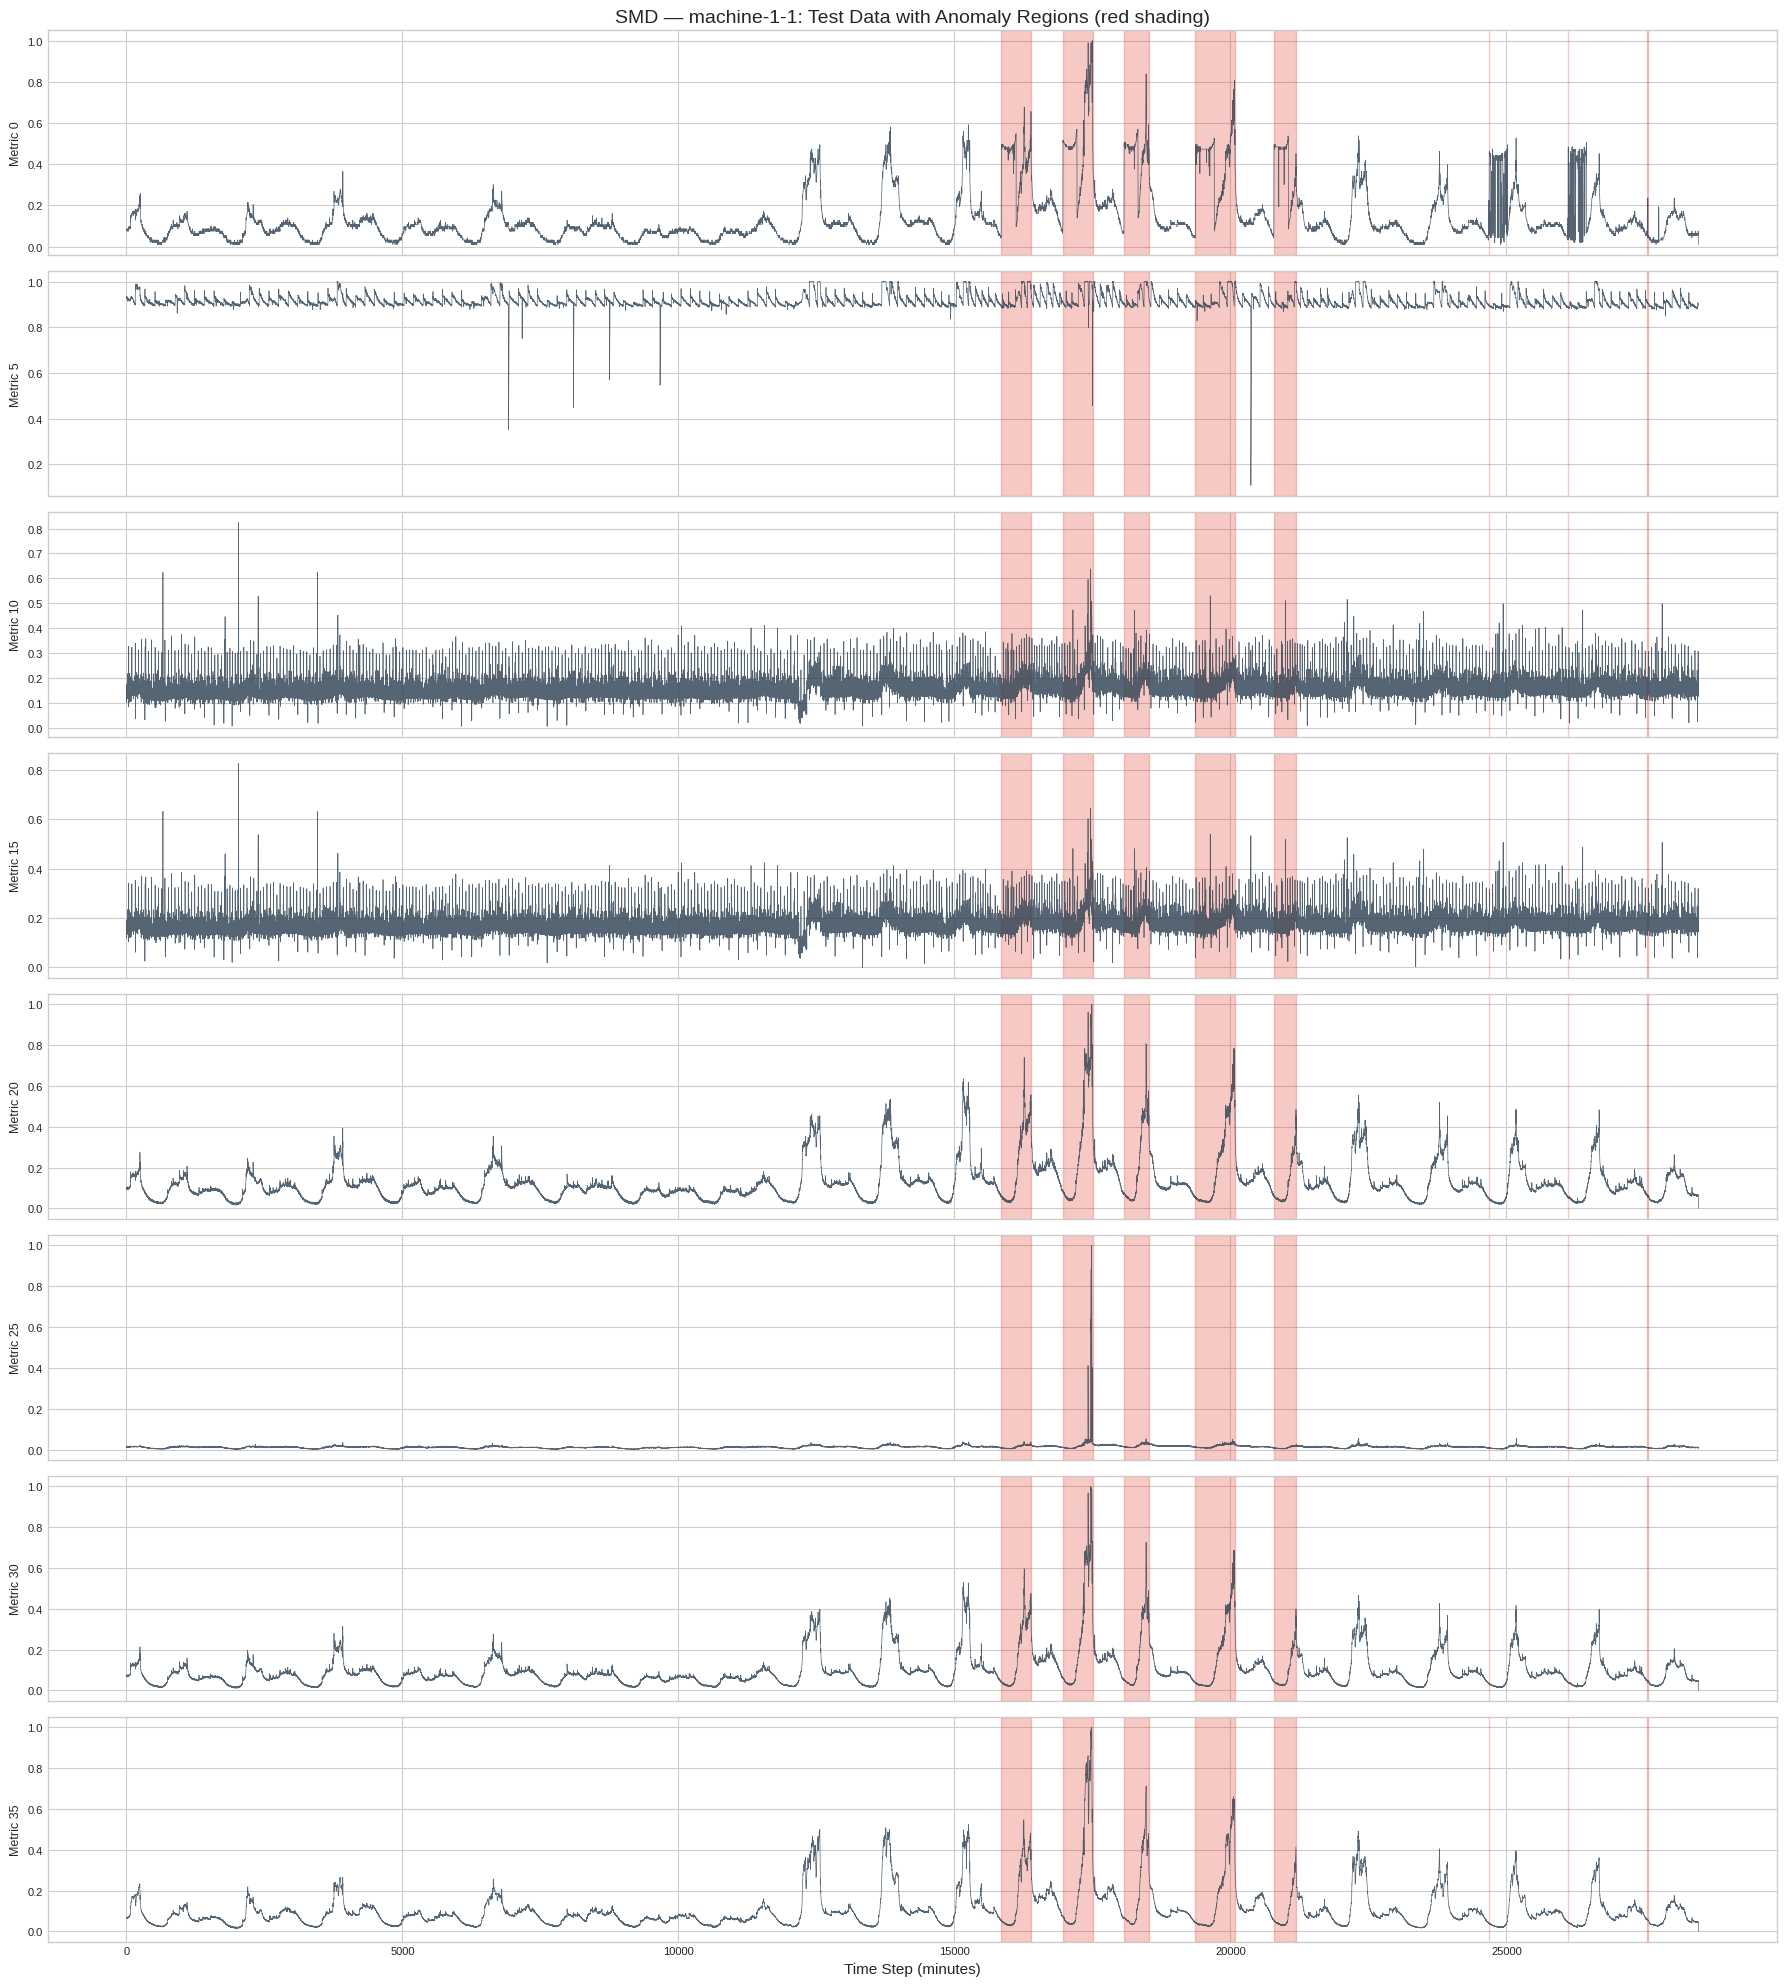

Machine: machine-1-1
Test length: 28479 time steps, Dimensions: 38
Number of anomaly segments: 8
Total anomaly points: 2694 (9.46%)


In [4]:
# Pick a machine with interesting anomalies
machine_name = 'machine-1-1'
train, test, labels = load_machine_data(machine_name)

# Select a few representative dimensions
selected_dims = [0, 5, 10, 15, 20, 25, 30, 35]
dim_names = [f'Metric {d}' for d in selected_dims]

fig, axes = plt.subplots(len(selected_dims), 1, figsize=(18, 2.5 * len(selected_dims)), sharex=True)

for i, (dim, name) in enumerate(zip(selected_dims, dim_names)):
    ax = axes[i]
    ax.plot(test[:, dim], color='#2c3e50', linewidth=0.5, alpha=0.8)
    
    # Highlight anomaly regions
    anomaly_starts = []
    anomaly_ends = []
    in_anomaly = False
    for t in range(len(labels)):
        if labels[t] == 1 and not in_anomaly:
            anomaly_starts.append(t)
            in_anomaly = True
        elif labels[t] == 0 and in_anomaly:
            anomaly_ends.append(t)
            in_anomaly = False
    if in_anomaly:
        anomaly_ends.append(len(labels))
    
    for s, e in zip(anomaly_starts, anomaly_ends):
        ax.axvspan(s, e, alpha=0.3, color='#e74c3c')
    
    ax.set_ylabel(name, fontsize=9)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Time Step (minutes)')
axes[0].set_title(f'SMD — {machine_name}: Test Data with Anomaly Regions (red shading)', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Machine: {machine_name}")
print(f"Test length: {len(test)} time steps, Dimensions: {test.shape[1]}")
print(f"Number of anomaly segments: {len(anomaly_starts)}")
print(f"Total anomaly points: {int(labels.sum())} ({labels.mean()*100:.2f}%)")


## 3. Cross-Machine Behavioral Similarity (Clustering Potential)

To demonstrate the **clustering potential** of SMD, we compute the mean feature profile for each machine and visualize the pairwise correlation matrix. Machines within the same group should exhibit similar behavioral patterns, forming natural clusters.


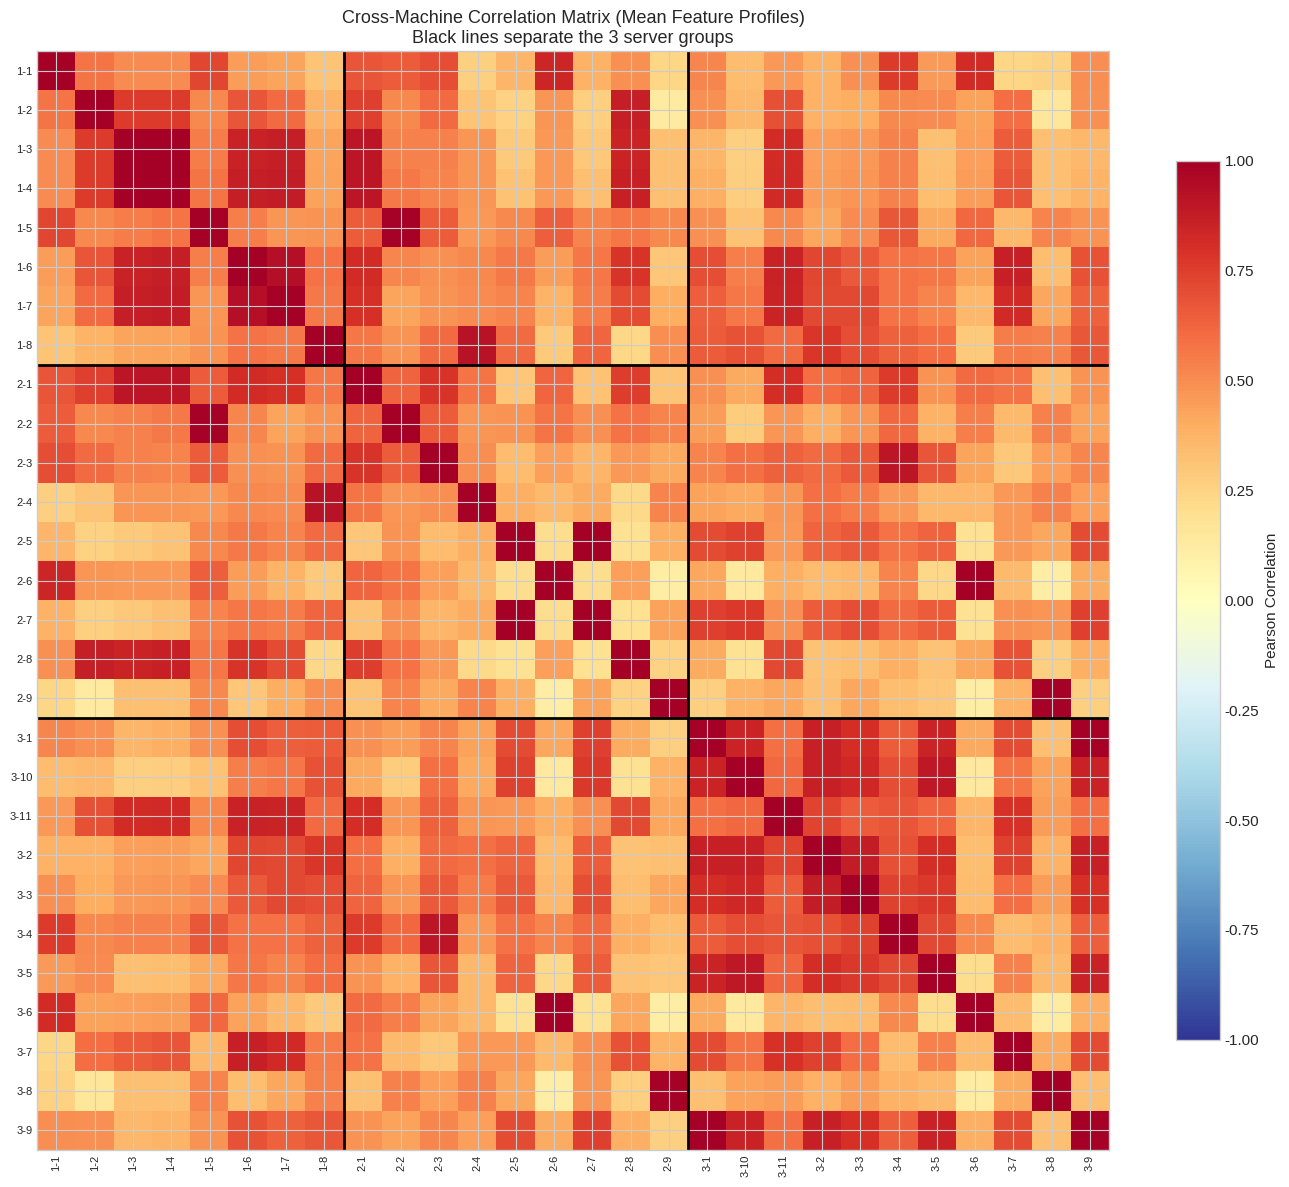

Key Insight: Machines within the same group show higher correlation,
confirming the natural cluster structure suitable for TICC-style clustering.


In [5]:
# Compute mean feature profiles for each machine (using train data)
profiles = []
for m in machines:
    train = np.loadtxt(os.path.join(TRAIN_DIR, f'{m}.txt'), delimiter=',')
    profiles.append(train.mean(axis=0))

profiles = np.array(profiles)

# Compute correlation matrix between machines
corr_matrix = np.corrcoef(profiles)

# Create annotated heatmap
fig, ax = plt.subplots(figsize=(14, 12))
group_labels = [m.split('-')[1] for m in machines]

# Create a mask for the group boundaries
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')

# Add group boundary lines
group_boundaries = [0]
current_group = group_labels[0]
for i, g in enumerate(group_labels):
    if g != current_group:
        group_boundaries.append(i)
        current_group = g
group_boundaries.append(len(machines))

for b in group_boundaries[1:-1]:
    ax.axhline(y=b - 0.5, color='black', linewidth=2)
    ax.axvline(x=b - 0.5, color='black', linewidth=2)

ax.set_xticks(range(len(machines)))
ax.set_yticks(range(len(machines)))
short_names = [m.replace('machine-', '') for m in machines]
ax.set_xticklabels(short_names, rotation=90, fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_title('Cross-Machine Correlation Matrix (Mean Feature Profiles)\nBlack lines separate the 3 server groups', fontsize=13)
plt.colorbar(im, ax=ax, label='Pearson Correlation', shrink=0.8)
plt.tight_layout()
plt.show()
print("Key Insight: Machines within the same group show higher correlation,")
print("confirming the natural cluster structure suitable for TICC-style clustering.")


## 4. Intra-Machine Feature Correlation

The 38 dimensions within each machine capture different system metrics (CPU, memory, network, disk, etc.). The correlation structure between features is crucial for multivariate anomaly detection methods like **MTAD-GAT** which model inter-feature dependencies.


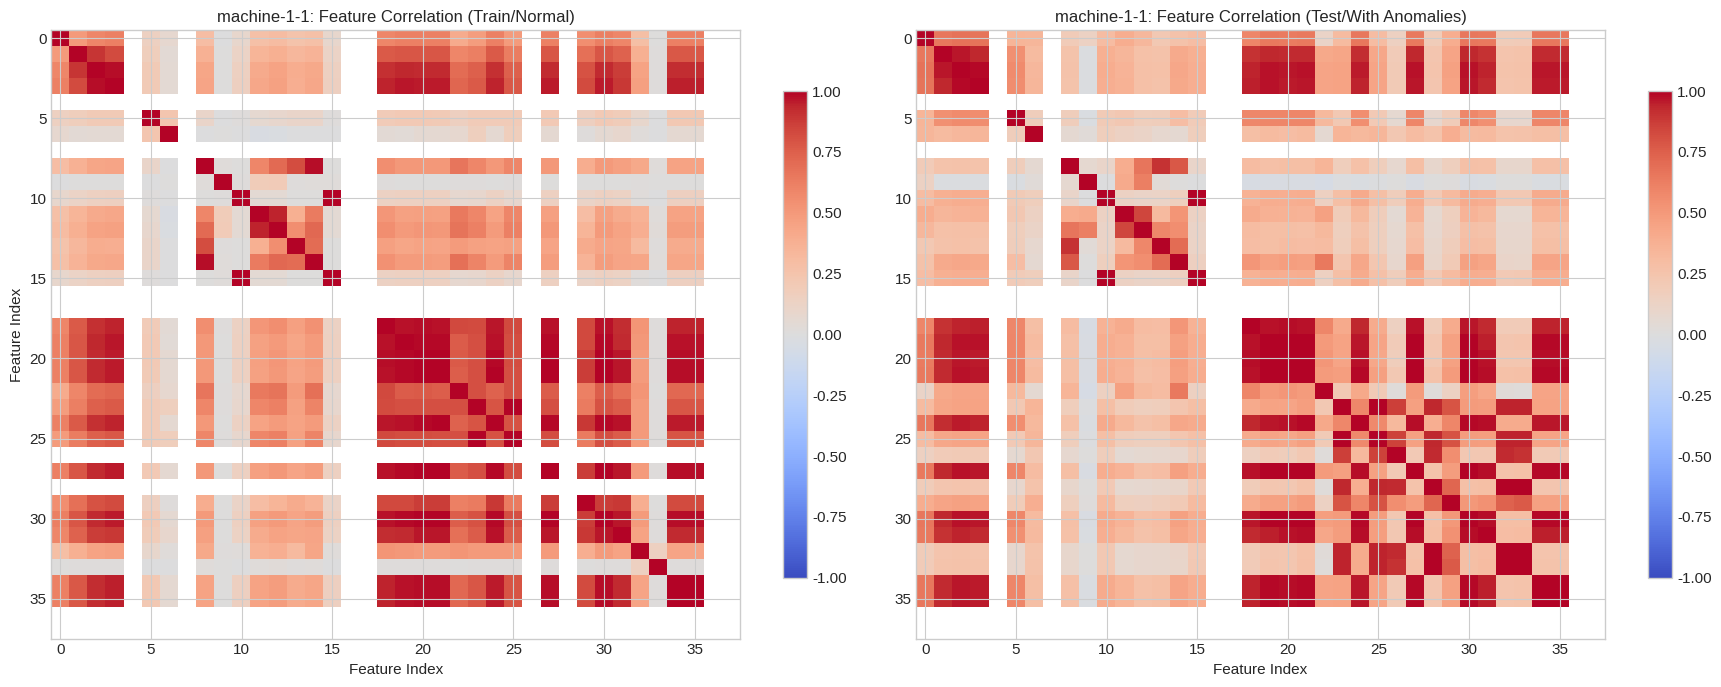

Key Insight: Anomalies can disrupt the normal correlation structure between features.
This is the basis for reconstruction-based AD methods that learn normal correlations.


In [6]:
# Feature correlation for one machine
machine_name = 'machine-1-1'
train = np.loadtxt(os.path.join(TRAIN_DIR, f'{machine_name}.txt'), delimiter=',')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normal data correlation
corr_normal = np.corrcoef(train.T)
im1 = axes[0].imshow(corr_normal, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title(f'{machine_name}: Feature Correlation (Train/Normal)', fontsize=12)
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Feature Index')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Test data correlation (includes anomalies)
test = np.loadtxt(os.path.join(TEST_DIR, f'{machine_name}.txt'), delimiter=',')
corr_test = np.corrcoef(test.T)
im2 = axes[1].imshow(corr_test, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title(f'{machine_name}: Feature Correlation (Test/With Anomalies)', fontsize=12)
axes[1].set_xlabel('Feature Index')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()
print("Key Insight: Anomalies can disrupt the normal correlation structure between features.")
print("This is the basis for reconstruction-based AD methods that learn normal correlations.")


## 5. Normal vs. Anomalous Feature Distributions

Comparing the distribution of features during normal operation vs. anomalous periods reveals the nature of anomalies in SMD. Some anomalies manifest as **distributional shifts**, while others are **contextual** (normal values in wrong temporal context).


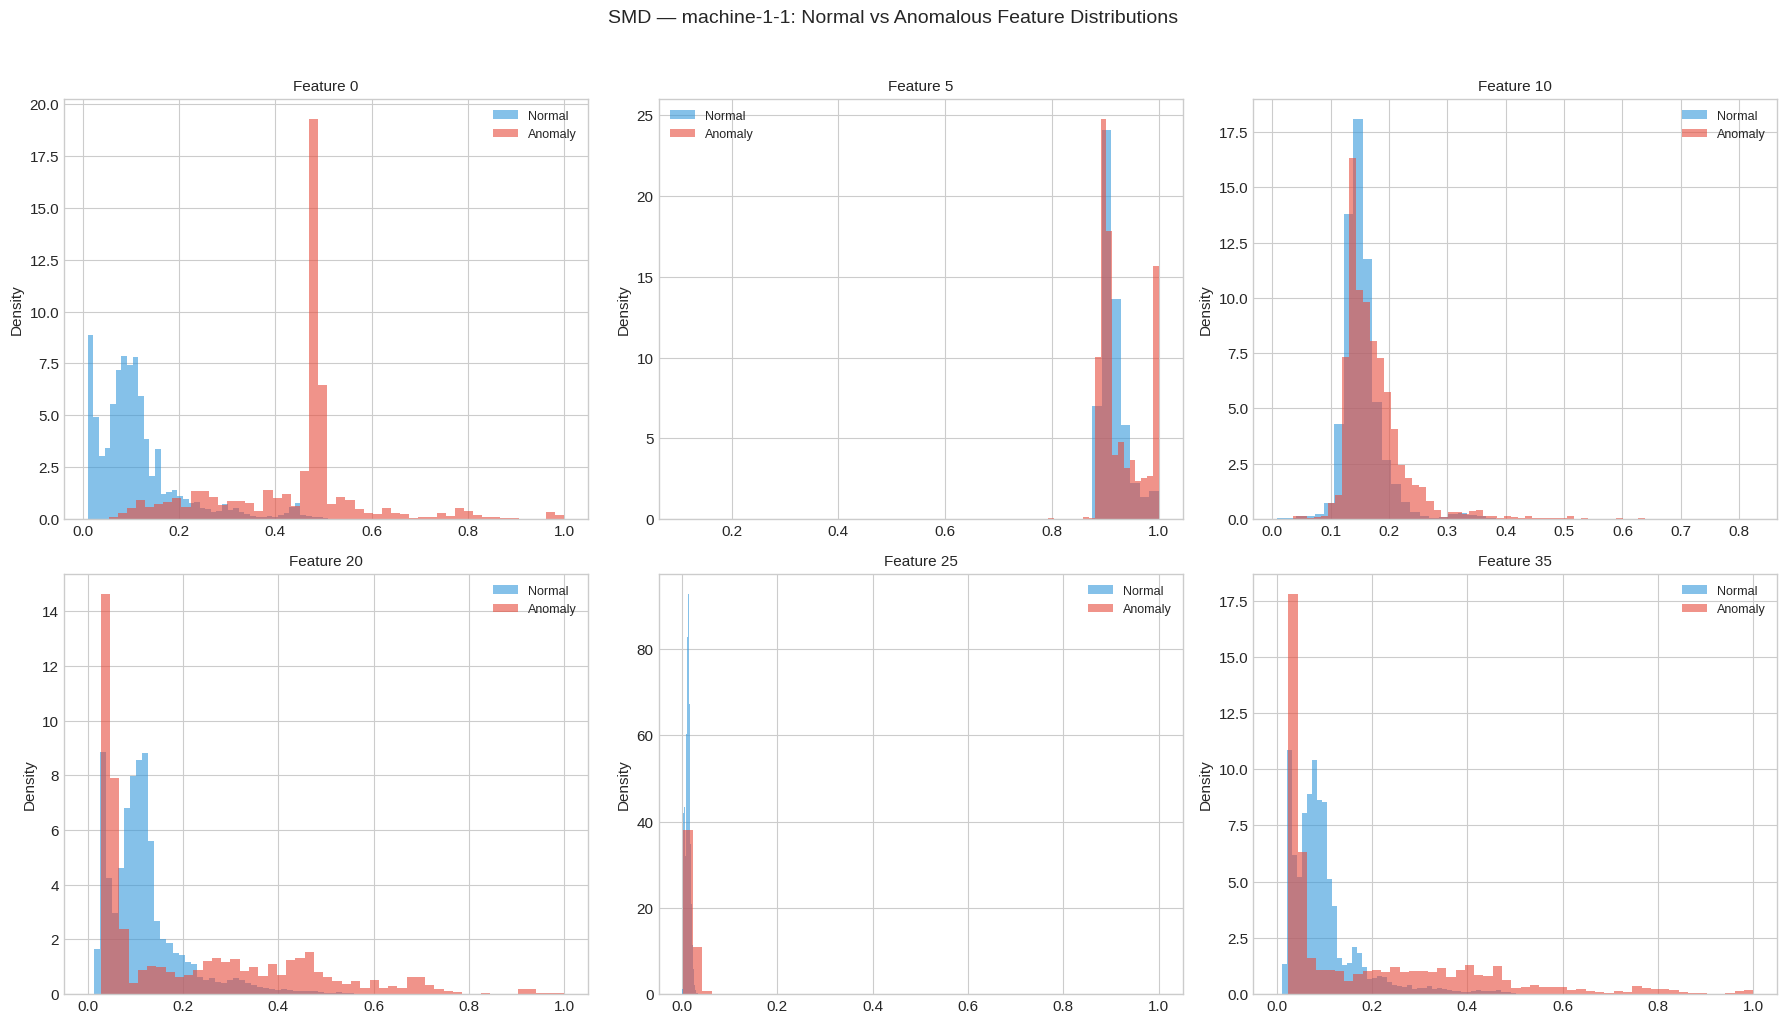

In [7]:
machine_name = 'machine-1-1'
test = np.loadtxt(os.path.join(TEST_DIR, f'{machine_name}.txt'), delimiter=',')
labels = np.loadtxt(os.path.join(LABEL_DIR, f'{machine_name}.txt'), delimiter=',')

normal_mask = labels == 0
anomaly_mask = labels == 1

# Select dimensions with most visible anomaly impact
selected_dims = [0, 5, 10, 20, 25, 35]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, dim in enumerate(selected_dims):
    ax = axes[i]
    ax.hist(test[normal_mask, dim], bins=50, alpha=0.6, color='#3498db', label='Normal', density=True)
    ax.hist(test[anomaly_mask, dim], bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
    ax.set_title(f'Feature {dim}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

plt.suptitle(f'SMD — {machine_name}: Normal vs Anomalous Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 6. Multi-Entity Comparison — Basis for Clustering

This visualization compares the same metric across multiple machines from different groups, demonstrating how **different server groups exhibit distinct operational patterns**. This is the foundation for applying TICC or similar MTS clustering algorithms.


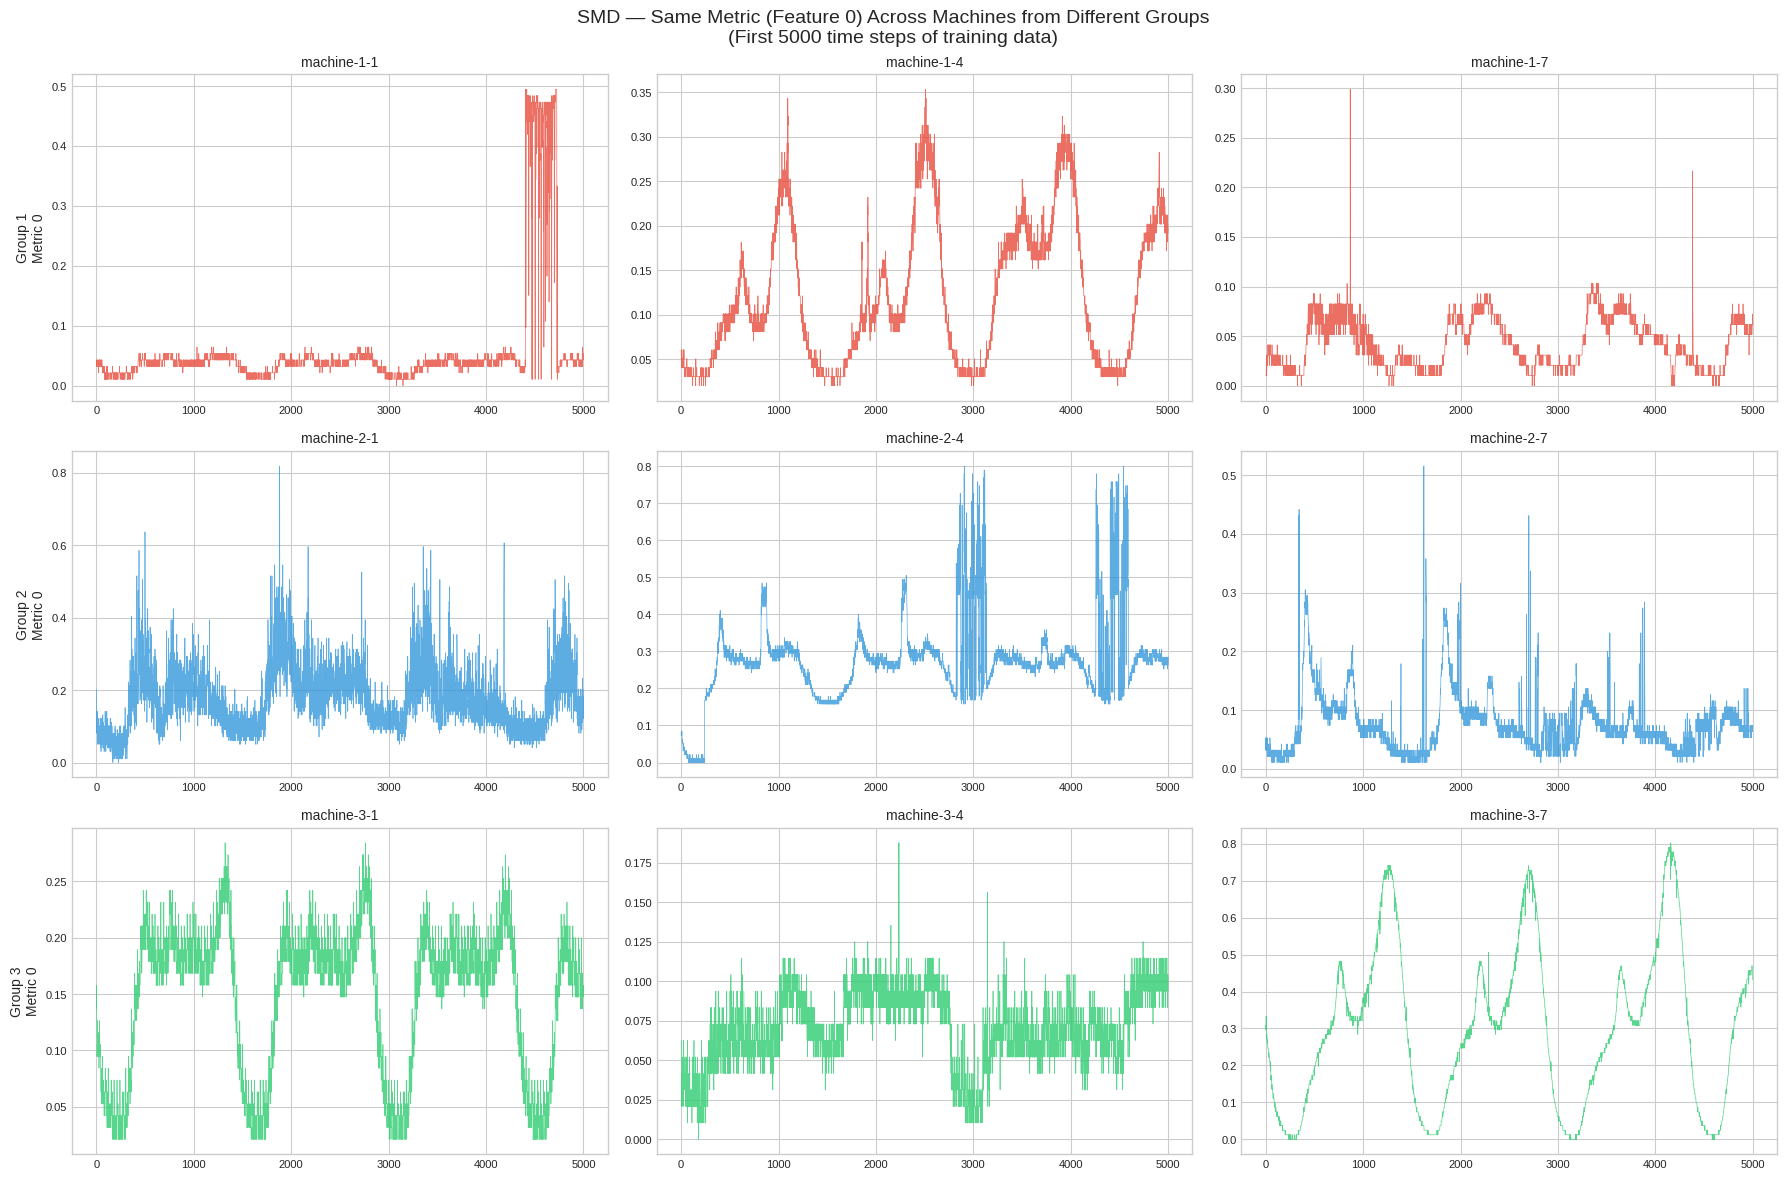

Key Insight: Machines within the same group share similar patterns,
while machines across groups show distinctly different behaviors.
This multi-entity structure is ideal for TICC-style clustering research.


In [8]:
# Compare same feature across machines from different groups
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

sample_machines = {
    1: ['machine-1-1', 'machine-1-4', 'machine-1-7'],
    2: ['machine-2-1', 'machine-2-4', 'machine-2-7'],
    3: ['machine-3-1', 'machine-3-4', 'machine-3-7']
}

feature_idx = 0  # First metric

for row, (group, machine_list) in enumerate(sample_machines.items()):
    for col, m in enumerate(machine_list):
        train = np.loadtxt(os.path.join(TRAIN_DIR, f'{m}.txt'), delimiter=',')
        ax = axes[row][col]
        # Plot first 5000 points for clarity
        ax.plot(train[:5000, feature_idx], color=list(colors.values())[group-1], linewidth=0.5, alpha=0.8)
        ax.set_title(f'{m}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'Group {group}\nMetric 0', fontsize=10)
        ax.tick_params(labelsize=8)

plt.suptitle('SMD — Same Metric (Feature 0) Across Machines from Different Groups\n(First 5000 time steps of training data)', fontsize=14)
plt.tight_layout()
plt.show()
print("Key Insight: Machines within the same group share similar patterns,")
print("while machines across groups show distinctly different behaviors.")
print("This multi-entity structure is ideal for TICC-style clustering research.")


## Summary: How SMD Supports Your Research

### Unsupervised Anomaly Detection
- **Point-level anomaly labels** across all 28 machines enable rigorous evaluation
- **Interpretation labels** identify which dimensions contribute to each anomaly
- High dimensionality (38 features) challenges reconstruction-based and forecasting-based methods
- Suitable for MTAD-GAT, OmniAnomaly, USAD, and similar architectures

### MTS Clustering
- **28 machines in 3 known groups** provide ground truth for clustering evaluation
- Cross-machine correlation analysis confirms distinct group behaviors
- TICC can discover operational regimes both within and across machines

### Predictive Maintenance / Early Detection
- Anomalies represent real system faults with temporal extent
- Precursor signals before anomaly onset can be studied for early warning
- Transfer learning across machines enables robust fault prediction models

### Complexity Assessment
- **Not saturated**: State-of-the-art F1 scores range from 0.75–0.92 depending on the machine
- **Active research**: Continuously used in top venues (KDD, NeurIPS, AAAI, VLDB)
- **Challenges**: Heterogeneous anomaly patterns, class imbalance, inter-machine variability


---

## 7. Operational Regime Discovery via Sliding-Window Statistics

A key hypothesis for TICC-style clustering on industrial MTS is that machines cycle through distinct **operational regimes** (e.g., warming up, steady-state high load, idle, transitioning). These regimes manifest as regions of locally stable statistics. Below, we compute rolling-window statistics on training data (assumed mostly normal) and visualize regime transitions.

**Important distinction**: Clusters are NOT anomaly types. A cluster = an operational phase/regime. Each phase can itself contain anomalies.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

# Paths (same as earlier cells)
DATA_DIR = 'smd'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
LABEL_DIR = os.path.join(DATA_DIR, 'test_label')

# --- Load machine-1-1 training data ---
machine_name = 'machine-1-1'
train = np.loadtxt(os.path.join(TRAIN_DIR, f'{machine_name}.txt'), delimiter=',')
print(f"Loaded {machine_name} train data: {train.shape}")

# --- Compute rolling-window statistics ---
WINDOW = 100  # ~100 minutes rolling window

# Convert to DataFrame for convenient rolling operations
train_df = pd.DataFrame(train, columns=[f'F{i}' for i in range(train.shape[1])])

# Pick 3 informative features for visualization
feat_ids = [0, 10, 25]
feat_names = [f'Feature {i}' for i in feat_ids]

rolling_mean = train_df[[f'F{i}' for i in feat_ids]].rolling(window=WINDOW, center=True).mean()
rolling_std  = train_df[[f'F{i}' for i in feat_ids]].rolling(window=WINDOW, center=True).std()
rolling_range = (
    train_df[[f'F{i}' for i in feat_ids]].rolling(window=WINDOW, center=True).max()
    - train_df[[f'F{i}' for i in feat_ids]].rolling(window=WINDOW, center=True).min()
)

print(f"Rolling window size: {WINDOW} time steps (~{WINDOW} minutes)")
print(f"Selected features for regime analysis: {feat_ids}")

In [ ]:
# --- Plot rolling statistics to visualize regime transitions ---
fig, axes = plt.subplots(3, 3, figsize=(20, 12), sharex=True)

stat_labels = ['Rolling Mean', 'Rolling Std', 'Rolling Range']
stat_data = [rolling_mean, rolling_std, rolling_range]
stat_colors = ['#2c3e50', '#e67e22', '#8e44ad']

for col, (stat_name, stat_df, color) in enumerate(zip(stat_labels, stat_data, stat_colors)):
    for row, feat in enumerate(feat_ids):
        ax = axes[row][col]
        ax.plot(stat_df[f'F{feat}'].values, color=color, linewidth=0.6, alpha=0.8)
        ax.set_ylabel(f'Feature {feat}', fontsize=9)
        if row == 0:
            ax.set_title(stat_name, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)

axes[-1][1].set_xlabel('Time Step (minutes)', fontsize=11)
fig.suptitle(f'SMD {machine_name} (Train) — Rolling-Window Statistics (w={WINDOW})\n'
             'Regime transitions appear as sustained shifts in local statistics',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Observation: Notice how rolling mean and std shift between plateaus.")
print("Each plateau corresponds to a distinct operational regime (e.g., high-load vs. idle).")

In [ ]:
# --- Scatter plot: Rolling Mean vs Rolling Std, colored by time ---
# This reveals regime clusters in statistic-space WITHOUT any labels.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
time_idx = np.arange(len(rolling_mean))
norm = Normalize(vmin=0, vmax=len(rolling_mean))

for i, feat in enumerate(feat_ids):
    ax = axes[i]
    col_name = f'F{feat}'
    mask = rolling_mean[col_name].notna()  # drop NaN edges from rolling
    sc = ax.scatter(
        rolling_mean[col_name][mask],
        rolling_std[col_name][mask],
        c=time_idx[mask],
        cmap='viridis',
        s=2,
        alpha=0.5,
        rasterized=True
    )
    ax.set_xlabel(f'Rolling Mean (w={WINDOW})', fontsize=10)
    ax.set_ylabel(f'Rolling Std (w={WINDOW})', fontsize=10)
    ax.set_title(f'Feature {feat}', fontsize=12)

# Shared colorbar
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap='viridis'), ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Time Step', fontsize=11)

fig.suptitle(f'SMD {machine_name} (Train) — Rolling Mean vs. Std Scatter (colored by time)\n'
             'Distinct clusters in this space correspond to operational regimes',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

print("Key Insight: The visible clusters in (mean, std) space are operational regimes.")
print("TICC-style algorithms discover these automatically by clustering sliding windows")
print("based on their local Gaussian graphical model (covariance structure).")

**Interpretation**: These regime transitions are what TICC-style clustering would discover. The scatter plots above show that even simple summary statistics (mean, std) over sliding windows reveal distinct clusters in feature space. Each cluster corresponds to an operational phase — for example, high mean + low variance might indicate steady high-load operation, while low mean + high variance might indicate a transitioning or fluctuating state.

**Note**: Each regime can contain anomalies within it. The clustering task is orthogonal to anomaly detection: first discover *what regime the machine is in*, then detect *whether something is going wrong within that regime*. This two-stage perspective is a promising research direction.

---

## 8. Anomaly Precursor Analysis (Early Detection Potential)

For predictive maintenance and early anomaly detection, the critical question is: **do features exhibit detectable drift BEFORE the labeled anomaly begins?** If so, a model could raise an alert earlier than the ground-truth label suggests.

Below we zoom into the test data for machine-1-1, focusing on the window leading up to the first anomaly segment. We also compute rolling Z-scores to quantify how early the deviation becomes statistically significant.

In [ ]:
# --- Load test data and labels for machine-1-1 ---
machine_name = 'machine-1-1'
train = np.loadtxt(os.path.join(TRAIN_DIR, f'{machine_name}.txt'), delimiter=',')
test = np.loadtxt(os.path.join(TEST_DIR, f'{machine_name}.txt'), delimiter=',')
labels = np.loadtxt(os.path.join(LABEL_DIR, f'{machine_name}.txt'), delimiter=',')

# Find the first anomaly segment
anomaly_starts = []
in_anomaly = False
for t in range(len(labels)):
    if labels[t] == 1 and not in_anomaly:
        anomaly_starts.append(t)
        in_anomaly = True
    elif labels[t] == 0 and in_anomaly:
        in_anomaly = False

first_anomaly_start = anomaly_starts[0]
print(f"First anomaly segment starts at time step: {first_anomaly_start}")

# Define the precursor analysis window: 500 steps before + 200 steps into anomaly
PRE_WINDOW = 500
POST_WINDOW = 200
win_start = max(0, first_anomaly_start - PRE_WINDOW)
win_end = min(len(test), first_anomaly_start + POST_WINDOW)

# Select features that show interesting precursor behavior
# We look at several features and pick ones with visible drift
selected_feats = [0, 5, 10, 15, 20, 25]

fig, axes = plt.subplots(len(selected_feats), 1, figsize=(18, 2.5 * len(selected_feats)), sharex=True)

for i, feat in enumerate(selected_feats):
    ax = axes[i]
    time_slice = np.arange(win_start, win_end)
    values = test[win_start:win_end, feat]
    
    ax.plot(time_slice, values, color='#2c3e50', linewidth=0.8, alpha=0.9)
    
    # Shade anomaly region
    ax.axvspan(first_anomaly_start, win_end, alpha=0.25, color='#e74c3c', label='Labeled Anomaly')
    
    # Mark the anomaly onset
    ax.axvline(first_anomaly_start, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    
    ax.set_ylabel(f'Feature {feat}', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time Step', fontsize=11)
axes[0].set_title(
    f'SMD {machine_name} — Zoom into {PRE_WINDOW} steps BEFORE first anomaly onset\n'
    f'Red dashed line = labeled anomaly start (t={first_anomaly_start})',
    fontsize=13
)
plt.tight_layout()
plt.show()

print(f"Window shown: t={win_start} to t={win_end}")
print("Look for gradual drift or increasing volatility BEFORE the red dashed line.")

In [ ]:
# --- Rolling Z-score analysis: when does deviation become detectable? ---
# Compute Z-score relative to training data statistics (the "normal" baseline)
train_mean = train.mean(axis=0)
train_std = train.std(axis=0)
# Avoid division by zero for constant features
train_std[train_std == 0] = 1.0

# Compute point-wise Z-score on test data
z_scores = np.abs((test - train_mean) / train_std)

# Compute rolling max Z-score (smoothed) to reduce noise
ZSCORE_WINDOW = 50
z_df = pd.DataFrame(z_scores[:, selected_feats], columns=[f'F{f}' for f in selected_feats])
rolling_z = z_df.rolling(window=ZSCORE_WINDOW, center=True).mean()

# Plot rolling Z-scores in the precursor window
fig, axes = plt.subplots(len(selected_feats), 1, figsize=(18, 2.5 * len(selected_feats)), sharex=True)

ZSCORE_THRESHOLD = 2.0  # Standard threshold for "unusual"

for i, feat in enumerate(selected_feats):
    ax = axes[i]
    col = f'F{feat}'
    time_slice = np.arange(win_start, win_end)
    z_vals = rolling_z[col].values[win_start:win_end]
    
    ax.plot(time_slice, z_vals, color='#2c3e50', linewidth=1.0, alpha=0.9)
    ax.axhline(ZSCORE_THRESHOLD, color='orange', linewidth=1.2, linestyle='--', alpha=0.7, label=f'Z={ZSCORE_THRESHOLD}')
    ax.axvspan(first_anomaly_start, win_end, alpha=0.20, color='#e74c3c')
    ax.axvline(first_anomaly_start, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    
    # Find earliest point where Z-score exceeds threshold in the pre-anomaly window
    pre_z = rolling_z[col].values[win_start:first_anomaly_start]
    exceedance_idx = np.where(pre_z > ZSCORE_THRESHOLD)[0]
    if len(exceedance_idx) > 0:
        first_exceed = win_start + exceedance_idx[0]
        lead_time = first_anomaly_start - first_exceed
        ax.axvline(first_exceed, color='green', linewidth=1.2, linestyle=':', alpha=0.8)
        ax.annotate(f'Lead: {lead_time} steps', xy=(first_exceed, ZSCORE_THRESHOLD),
                   fontsize=8, color='green', fontweight='bold')
    
    ax.set_ylabel(f'Feature {feat}\n|Z-score|', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('Time Step', fontsize=11)
axes[0].set_title(
    f'SMD {machine_name} — Rolling Z-Score (w={ZSCORE_WINDOW}) Before First Anomaly\n'
    f'Green dotted line = earliest Z>{ZSCORE_THRESHOLD} detection in pre-anomaly window',
    fontsize=13
)
plt.tight_layout()
plt.show()

print("If green lines appear BEFORE the red dashed line, the feature started deviating")
print("before the labeled anomaly — this is the early detection lead time.")

**Interpretation**: This pre-anomaly drift is the signal that early detection / predictive maintenance methods aim to capture. Even a simple rolling Z-score can sometimes detect deviation before the official anomaly label begins, suggesting that:

1. **The ground-truth labels may be conservative** — the system was already degrading before it was officially flagged.
2. **Lead time varies by feature** — some metrics are leading indicators (e.g., CPU temperature rising before a crash), while others are lagging (e.g., error counts only spike at failure time).
3. **Multi-feature fusion is essential** — combining Z-scores across features could yield more reliable early warnings than any single feature alone.

This motivates research into **early anomaly detection** and **remaining useful lifetime (RUL)** estimation on SMD.

---

## 9. Multi-Scale Temporal Structure

Industrial time series often contain patterns at multiple temporal scales: rapid fluctuations at the minute level, periodic trends at the hour level, and slow drifts over days. Understanding which scale carries the most relevant signal is critical for choosing the right window size in clustering and anomaly detection.

Below we show the same feature at three temporal resolutions: raw (1-minute), 10-minute average, and 1-hour average. This demonstrates the multi-scale structure relevant for clustering at different granularities.

In [ ]:
# --- Multi-scale temporal analysis for machine-1-1 train data ---
machine_name = 'machine-1-1'
train = np.loadtxt(os.path.join(TRAIN_DIR, f'{machine_name}.txt'), delimiter=',')

# Select two features to show multi-scale patterns
feat_ids_ms = [0, 25]

# Temporal resolutions: raw (1-min), 10-min avg, 60-min (1-hour) avg
resolutions = [
    ('Raw (1-min)', 1),
    ('10-min average', 10),
    ('1-hour average', 60),
]

fig, axes = plt.subplots(len(feat_ids_ms), len(resolutions), figsize=(20, 4 * len(feat_ids_ms)), sharex=False)

for row, feat in enumerate(feat_ids_ms):
    raw_signal = train[:, feat]
    
    for col, (res_label, res_size) in enumerate(resolutions):
        ax = axes[row][col]
        
        if res_size == 1:
            # Raw signal
            ax.plot(raw_signal, color='#2c3e50', linewidth=0.3, alpha=0.8)
            ax.set_xlabel('Time (minutes)', fontsize=9)
        else:
            # Downsample by averaging non-overlapping blocks
            n_blocks = len(raw_signal) // res_size
            downsampled = raw_signal[:n_blocks * res_size].reshape(n_blocks, res_size).mean(axis=1)
            time_axis = np.arange(n_blocks) * res_size
            ax.plot(time_axis, downsampled, color='#2c3e50', linewidth=0.8, alpha=0.9)
            ax.set_xlabel(f'Time (minutes, {res_label})', fontsize=9)
        
        if row == 0:
            ax.set_title(res_label, fontsize=12, fontweight='bold')
        ax.set_ylabel(f'Feature {feat}', fontsize=10)
        ax.tick_params(labelsize=8)

fig.suptitle(
    f'SMD {machine_name} (Train) — Same Features at Different Temporal Resolutions\n'
    'Coarser resolutions reveal slow regime transitions; finer resolutions show rapid fluctuations',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

total_minutes = len(train)
print(f"Total training duration: {total_minutes} minutes = {total_minutes/60:.1f} hours = {total_minutes/1440:.1f} days")
print(f"\nAt 1-min resolution:  {total_minutes:,} data points per feature")
print(f"At 10-min resolution: {total_minutes//10:,} data points per feature")
print(f"At 1-hour resolution: {total_minutes//60:,} data points per feature")
print("\nMulti-scale insight: High-frequency noise dominates at 1-min scale.")
print("At 10-min and 1-hour scales, regime transitions become clearly visible —")
print("this suggests clustering algorithms may benefit from operating on downsampled data.")

---

## 10. Dataset Suitability Assessment for PhD Research

### Task Suitability Scores

| Research Task | Score | Justification |
|---|:---:|---|
| **MTS Clustering** | 7/10 | **Strengths**: 28 machines in 3 known server groups provide ground truth for inter-machine clustering evaluation. Intra-machine regime transitions (shown in Section 7) offer a second level of clustering granularity. The 38-dimensional feature space is rich enough for TICC-style Gaussian graphical model clustering. **Limitations**: Only 3 groups is a small number of clusters; no explicit regime labels exist within machines, so intra-machine clustering evaluation requires proxy metrics (e.g., stability, silhouette scores on rolling statistics). |
| **Unsupervised Anomaly Detection** | 9/10 | **Strengths**: Point-level anomaly labels across all 28 machines enable rigorous evaluation with standard metrics (F1, precision, recall, AUROC). Interpretation labels identify contributing dimensions for each anomaly. High dimensionality (38 features) and diverse anomaly patterns (distributional shifts, contextual anomalies, collective anomalies) challenge state-of-the-art methods. The train/test split with normal training data fits the unsupervised AD paradigm perfectly. **Limitations**: Anomaly ratios vary widely (0.4%--15.6%), and some anomalies may be mislabeled or ambiguous. Point-adjust F1 (the standard evaluation) is known to inflate scores. |
| **Early Detection / Predictive Maintenance / RUL** | 5/10 | **Strengths**: Anomalies represent real server faults with temporal extent, and some show detectable precursor signals (Section 8). Multiple anomaly segments per machine allow studying repeated failure patterns. **Limitations**: No explicit failure timestamps or RUL labels exist — anomaly labels mark the failure *window*, not the progression toward failure. The dataset was not designed for RUL estimation, so lead-time analysis requires heuristic definitions. Compared to dedicated predictive maintenance datasets (C-MAPSS, FEMTO), SMD lacks degradation trajectory annotations. |

### Key Strengths of SMD for Your Research
- **Real-world industrial data** from a production environment (not simulated)
- **Multi-entity structure** (28 machines, 3 groups) enables cross-machine transfer and clustering
- **High dimensionality** (38 features) representative of real monitoring systems
- **Continuous active use** in top ML/systems venues (KDD, NeurIPS, AAAI, VLDB) — results are directly comparable to recent literature
- **Interpretation labels** allow feature-level anomaly attribution analysis

### Key Limitations
- **No explicit regime/phase labels** — clustering evaluation within machines requires unsupervised metrics
- **Fixed 1-minute granularity** — no raw sub-minute data for higher-frequency analysis
- **Server-specific context** — patterns may not transfer to manufacturing/industrial plant settings
- **Label quality** — some anomaly boundaries are likely approximate; no severity scores

### Concrete Next Steps

**For Clustering:**
1. Apply TICC (Toeplitz Inverse Covariance Clustering) on individual machines using sliding windows of varying sizes (50, 100, 200 steps) and evaluate cluster stability
2. Compare intra-machine regime clustering with inter-machine group clustering — are they complementary signals?
3. Investigate whether regime-aware anomaly detection (cluster first, then detect within each regime) outperforms regime-agnostic approaches

**For Unsupervised Anomaly Detection:**
1. Benchmark reconstruction-based (AE, VAE, OmniAnomaly) vs. forecasting-based (MTAD-GAT) vs. contrastive methods on all 28 machines
2. Analyze per-machine performance variance — which machine characteristics predict AD difficulty?
3. Explore using the interpretation labels for feature-level anomaly detection evaluation

**For Early Detection / Predictive Maintenance:**
1. Systematically measure lead times across all anomaly segments using the Z-score approach from Section 8
2. Define a "pre-anomaly window" protocol (e.g., 100/200/500 steps before labeled onset) and evaluate whether models can detect impending failures
3. Consider combining SMD with a dedicated RUL dataset (e.g., C-MAPSS) for a comparative study on transfer of early-detection methods across domains